# 💳 Credit Card Fraud Detection — Imbalanced Machine Learning

## 🎯 Objective
Build a robust model to detect fraudulent transactions using techniques designed for highly imbalanced datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
sns.set_style('whitegrid')

## 📂 Data Loading

In [2]:
df=pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

## 🔍 Initial Exploration

In [3]:
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

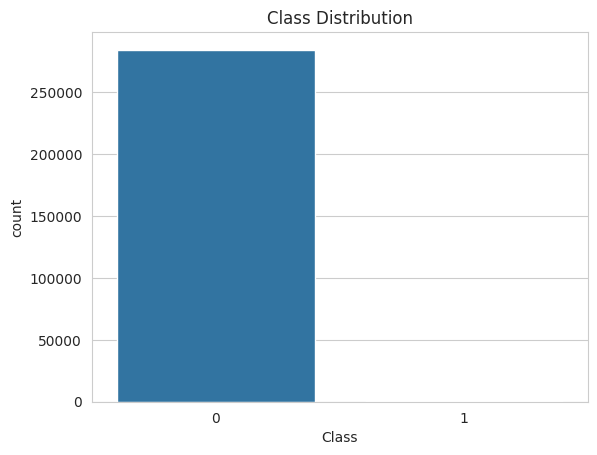

In [5]:
sns.countplot(x='Class',data=df)
plt.title('Class Distribution')
plt.show()

## 📊 Insight
The dataset is highly imbalanced, making accuracy unreliable. Recall and ROC-AUC are more appropriate metrics.

In [6]:
fraud_ratio=df['Class'].mean()
print('Fraud Ratio:',fraud_ratio)

Fraud Ratio: 0.001727485630620034


In [7]:
corr=df.corr()['Class'].sort_values(ascending=False)
print(corr.head(10))

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


Text(0.5, 1.0, 'Amount Distribution by Class')

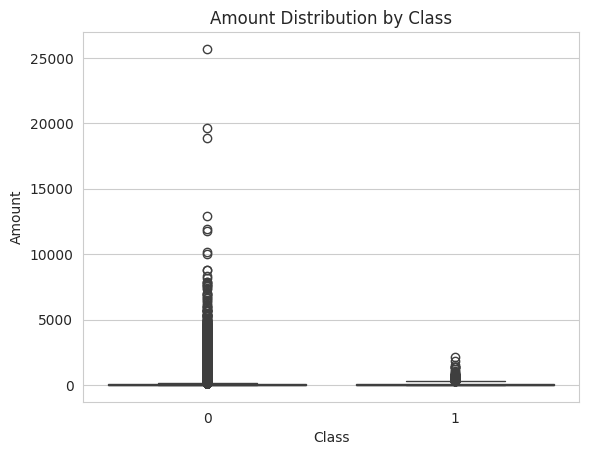

In [8]:
sns.boxplot(x='Class',y='Amount',data=df)
plt.title('Amount Distribution by Class')

- Dataset is highly imbalanced
- Fraud cases are extremely rare
- Accuracy is not a reliable metric

## ⚙️ Feature Engineering

In [9]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

df['Amount_scaled']=scaler.fit_transform(df[['Amount']])
df['Time_scaled']=scaler.fit_transform(df[['Time']])

df=df.drop(['Amount','Time'],axis=1)

In [10]:
from sklearn.model_selection import train_test_split

x=df.drop('Class',axis=1)
y=df['Class']

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
x_res,y_res=smote.fit_resample(x_train,y_train)

print('Resampled:',y_res.value_counts())

Resampled: Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)
rf.fit(x_res,y_res)

RandomForestClassifier(random_state=42)

In [14]:
from xgboost import XGBClassifier

xgb=XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=10,
    random_state=42
)

xgb.fit(x_res,y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [15]:
from sklearn.metrics import classification_report,roc_auc_score

probs_rf=rf.predict_proba(x_test)[:,1]
probs_xgb=xgb.predict_proba(x_test)[:,1]

print('RF ROC AUC',roc_auc_score(y_test,probs_rf))
print('XGB ROC AUC',roc_auc_score(y_test,probs_xgb))

RF ROC AUC 0.9688195357630954
XGB ROC AUC 0.9785850486086387


Text(0.5, 1.0, 'Precisin-Recall Curve')

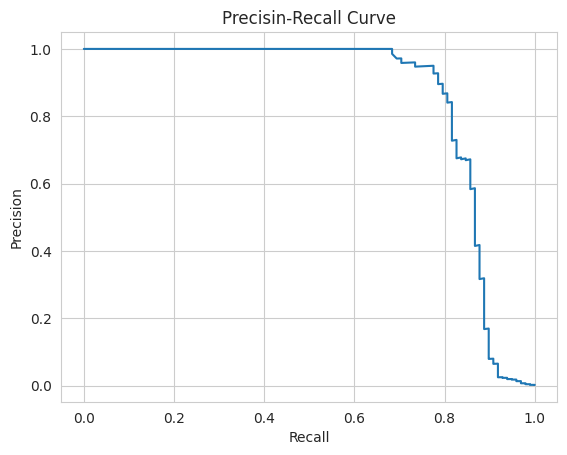

In [16]:
from sklearn.metrics import precision_recall_curve

precision,recall,thresholds=precision_recall_curve(y_test,probs_xgb)

plt.plot(recall,precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precisin-Recall Curve')

In [18]:
f1_scores=2*(precision * recall)/(precision + recall)

best_idx=np.argmax(f1_scores)
best_threshold=thresholds[best_idx]

print('Best Threshold',best_threshold)

Best Threshold 0.99833506


In [19]:
preds=(probs_xgb >= best_threshold).astype(int)

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.78      0.85        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [20]:
ensemble_probs=(0.6*probs_xgb + 0.4*probs_rf)

print('Ensemble ROC AUC:',roc_auc_score(y_test,ensemble_probs))

Ensemble ROC AUC: 0.9793152189829223


In [21]:
preds=(ensemble_probs >= best_threshold).astype(int)

print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       1.00      0.37      0.54        98

    accuracy                           1.00     56962
   macro avg       1.00      0.68      0.77     56962
weighted avg       1.00      1.00      1.00     56962



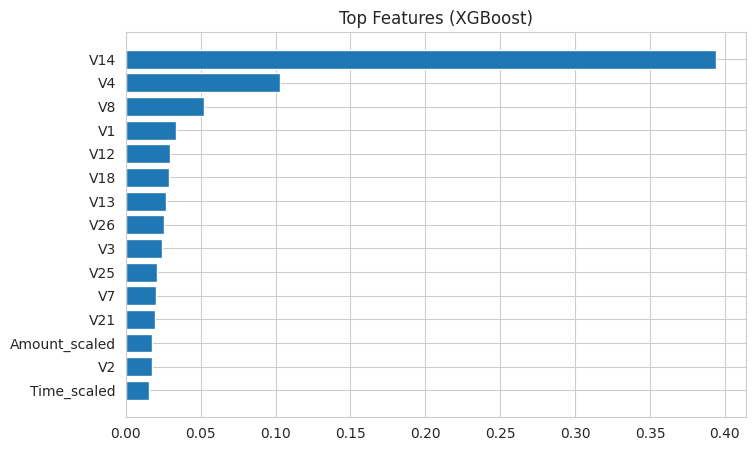

In [23]:
importances=xgb.feature_importances_
indices=np.argsort(importances)[-15:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)),importances[indices])
plt.yticks(range(len(indices)),x.columns[indices])
plt.title("Top Features (XGBoost)")
plt.show()

- Fraud detection requires high recall
- Imbalanced data significantly impacts performance
- XGBoost outperforms baseline models
- Ensemble methods provide best results
- Threshold tuning is critical for real-world deployment